# Controlled explosive-density sensitivity comparison

This notebook evaluates how the seven reconstructed conventional burden models respond when explosive density is varied while the other Gole Gohar reference inputs remain fixed.

> **Research-use safeguard:** This is a deterministic model-structure comparison. The sampled explosive densities are an exploratory analytical grid, not a recommended operational range, and the results are not validated blast-design recommendations.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt

from blastdesign import (
    build_explosive_density_ensemble_summary,
    build_gole_gohar_explosive_density_sensitivity_table,
    build_model_explosive_density_response_summary,
)


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
FIGURE_DIRECTORY = PROJECT_ROOT / "outputs" / "figures"

DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

## Method

Explosive density is varied from **0.70 to 1.00 g/cm³** in increments of **0.05 g/cm³**. The reconstructed reference value is **0.85 g/cm³**.

Hole diameter, rock density, UCS, explosive type, and all other reference inputs remain fixed. This one-factor-at-a-time design isolates the explicit explosive-density response of the reconstructed equations.

The explosive-to-rock density ratio is calculated for each sampled value. Only the Konya 1972 and Konya 1983 equations contain explosive density as an explicit input.

In [7]:
model_outputs = (
    build_gole_gohar_explosive_density_sensitivity_table()
)

ensemble_summary = (
    build_explosive_density_ensemble_summary(model_outputs)
)

model_response_summary = (
    build_model_explosive_density_response_summary(
        model_outputs
    )
)

display(model_outputs)
display(ensemble_summary)
display(model_response_summary)

,explosive_density_g_cm3,explosive_to_rock_density_ratio,model_id,model_name,burden_m
0,0.70,0.160183,CONV_ASH,Ash,6.275000
1,0.70,0.160183,CONV_BHANDARI,Bhandari,6.874000
2,0.70,0.160183,CONV_JIMENO,Lopez Jimeno,5.773000
3,0.70,0.160183,CONV_KONYA_1972,Konya 1972,5.184287
4,0.70,0.160183,CONV_KONYA_1983,Konya 1983,5.482943
5,0.70,0.160183,CONV_RUSTAN,Rustan,6.983189
6,0.70,0.160183,CONV_TATIYA,Tatiya–Al-Ajmi,5.839370
7,0.75,0.171625,CONV_ASH,Ash,6.275000
8,0.75,0.171625,CONV_BHANDARI,Bhandari,6.874000
9,0.75,0.171625,CONV_JIMENO,Lopez Jimeno,5.773000


,explosive_density_g_cm3,explosive_to_rock_density_ratio,model_count,mean_burden_m,median_burden_m,minimum_burden_m,maximum_burden_m,range_m
0,0.70,0.160183,7,6.058827,5.83937,5.184287,6.983189,1.798902
1,0.75,0.171625,7,6.085729,5.83937,5.303675,6.983189,1.679514
2,0.80,0.183066,7,6.111885,5.83937,5.417842,6.983189,1.565346
3,0.85,0.194508,7,6.137371,5.83937,5.527324,6.983189,1.455865
4,0.90,0.205950,7,6.162253,5.83937,5.632571,6.983189,1.350618
5,0.95,0.217391,7,6.186585,5.83937,5.733970,6.983189,1.249218
6,1.00,0.228833,7,6.210415,5.89649,5.773000,6.983189,1.210189


,model_id,model_name,distinct_burden_count,responds_to_explosive_density,lower_explosive_density_g_cm3,upper_explosive_density_g_cm3,burden_at_lower_endpoint_m,reference_explosive_density_g_cm3,reference_density_ratio,reference_burden_m,burden_at_upper_endpoint_m,endpoint_change_m,endpoint_change_percent,burden_range_m
0,CONV_ASH,Ash,1,False,0.7,1.0,6.275000,0.85,0.194508,6.275000,6.275000,0.000000,0.000000,0.000000
1,CONV_BHANDARI,Bhandari,1,False,0.7,1.0,6.874000,0.85,0.194508,6.874000,6.874000,0.000000,0.000000,0.000000
2,CONV_JIMENO,Lopez Jimeno,1,False,0.7,1.0,5.773000,0.85,0.194508,5.773000,5.773000,0.000000,0.000000,0.000000
3,CONV_KONYA_1972,Konya 1972,7,True,0.7,1.0,5.184287,0.85,0.194508,5.527324,5.831854,0.647567,12.490966,0.647567
4,CONV_KONYA_1983,Konya 1983,7,True,0.7,1.0,5.482943,0.85,0.194508,5.689716,5.896490,0.413547,7.542426,0.413547
5,CONV_RUSTAN,Rustan,1,False,0.7,1.0,6.983189,0.85,0.194508,6.983189,6.983189,0.000000,0.000000,0.000000
6,CONV_TATIYA,Tatiya–Al-Ajmi,1,False,0.7,1.0,5.839370,0.85,0.194508,5.839370,5.839370,0.000000,0.000000,0.000000


In [8]:
model_outputs.to_csv(
    DATA_DIRECTORY
    / "explosive_density_sensitivity_model_outputs.csv",
    index=False,
)

ensemble_summary.to_csv(
    DATA_DIRECTORY
    / "explosive_density_sensitivity_ensemble_summary.csv",
    index=False,
)

model_response_summary.to_csv(
    DATA_DIRECTORY
    / "explosive_density_sensitivity_model_response_summary.csv",
    index=False,
)

print("Saved all three explosive-density sensitivity tables.")

Saved all three explosive-density sensitivity tables.


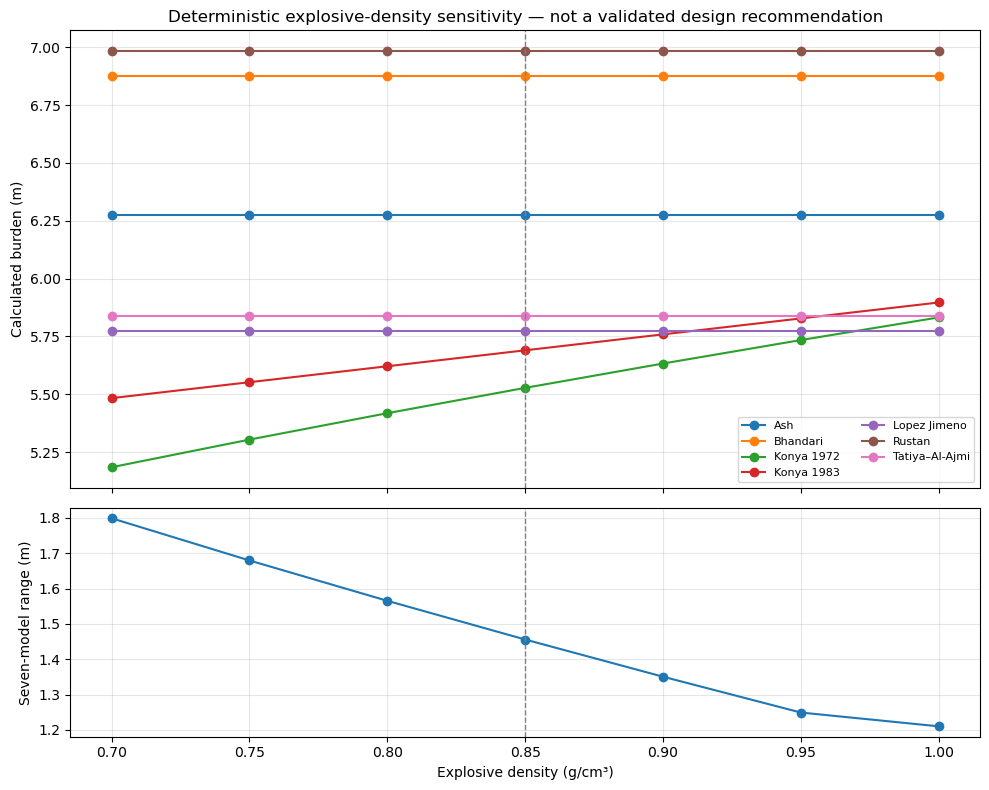

In [9]:
pivot_table = model_outputs.pivot(
    index="explosive_density_g_cm3",
    columns="model_name",
    values="burden_m",
)

figure, (burden_axis, range_axis) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

for model_name in pivot_table.columns:
    burden_axis.plot(
        pivot_table.index,
        pivot_table[model_name],
        marker="o",
        label=model_name,
    )

burden_axis.axvline(
    0.85,
    color="gray",
    linestyle="--",
    linewidth=1,
)

burden_axis.set_ylabel("Calculated burden (m)")
burden_axis.set_title(
    "Deterministic explosive-density sensitivity — "
    "not a validated design recommendation"
)
burden_axis.grid(alpha=0.3)
burden_axis.legend(ncol=2, fontsize=8)

range_axis.plot(
    ensemble_summary["explosive_density_g_cm3"],
    ensemble_summary["range_m"],
    marker="o",
)

range_axis.axvline(
    0.85,
    color="gray",
    linestyle="--",
    linewidth=1,
)

range_axis.set_xlabel("Explosive density (g/cm³)")
range_axis.set_ylabel("Seven-model range (m)")
range_axis.grid(alpha=0.3)

figure.tight_layout()

figure.savefig(
    FIGURE_DIRECTORY
    / "explosive_density_sensitivity_comparison.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [10]:
responsive_models = model_response_summary.loc[
    model_response_summary[
        "responds_to_explosive_density"
    ],
    "model_id",
].tolist()

print("Model-output shape:", model_outputs.shape)
print("Ensemble-summary shape:", ensemble_summary.shape)
print("Model-response-summary shape:", model_response_summary.shape)
print("Responsive models:", responsive_models)

Model-output shape: (49, 5)
Ensemble-summary shape: (7, 8)
Model-response-summary shape: (7, 14)
Responsive models: ['CONV_KONYA_1972', 'CONV_KONYA_1983']


## Interpretation

Only two reconstructed models respond directly to explosive density:

- Konya 1972 changes by approximately **0.648 m** between the sampled endpoints.
- Konya 1983 changes by approximately **0.414 m** between the sampled endpoints.
- The other five equations remain constant because explosive density is not an explicit input in their reconstructed forms.

Across the sampled grid, the seven-model burden range decreases from approximately **1.799 m** at 0.70 g/cm³ to **1.210 m** at 1.00 g/cm³. At the reconstructed reference density of **0.85 g/cm³**, the established range of approximately **1.456 m** is reproduced.

This variation represents deterministic sensitivity and structural disagreement among empirical equations. It must not be interpreted as:

- A statistical confidence interval.
- A calibrated prediction interval.
- Evidence that a particular model is more accurate.
- A recommended explosive-density range.
- A site-specific operational burden recommendation.